## Diseño del modelo de CNN como calsificador binario

Loss (Función de pérdida): Binary Crossentropy
✔ Optimizador: Adam
✔ Inicialización: Glorot Uniform
✔ CNN:
- Activación convolucional: tanh
- Activación capas densas: ReLU
- Mismo nº filtros, kernel y pool en todas las conv layers
- MaxPooling = 2
- Máx 10 capas convolucionales

✔ Capa Densa:

Cada capa tiene la mitad de neuronas que la anterior

✔ Entrenamiento:

Dataset balanceado (light vs dark): 1000 light y 1000 dark

Split: 80% train / 20% validation

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from sklearn.model_selection import train_test_split

I0000 00:00:1774811455.400453   36085 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774811458.327336   36085 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774811469.086028   36085 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
tree_light_data = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_data"]
tree_light_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_parameters"]
tree_dark_data = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_data"]
tree_dark_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_parameters"]
light_pulses = tree_light_data["dataChA"].array(library="np")
dark_pulses = tree_dark_data["dataChA"].array(library="np")

In [3]:
import matplotlib.ticker as ticker

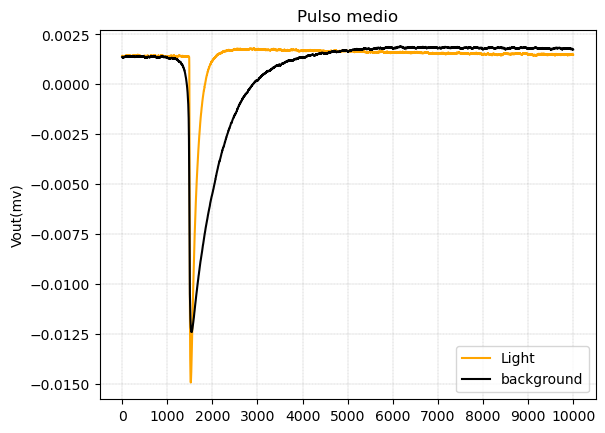

In [4]:
mean_light = np.mean(light_pulses, axis=0)
mean_dark = np.mean(dark_pulses, axis=0)

plt.plot(mean_light, label="Light", color = 'orange')
plt.plot(mean_dark, label="background", color = 'black')

plt.legend()
plt.title("Pulso medio")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

## División del conjunto de datos
Incialmente trabajaremos con los 4722 pulsos. Sin embargo, para reducir la carga computacional durante el entrenamiento del modelo, se ha decidido seleccionar una ventana de muestras significativas. Para ello se ha calculado el pulso medio del conjunto de datos light y dark. Se observa que la media en ambos casos se centra en el margen de muestra de 1000 a 2000 muestras. Ajustando un poco más, se ha tomado como inicio 1200 como inicio. Se observa que los pulsos dark tienen mayor dispersión, para que el modelo tenga más información de los pulsos dark, se ha decidido, tomar como limite final, 2200.

Otros detalles:
- Hasta este punto, tanto el conjunto de datos light como dark son arrays unidimensionales, cada uno de ellos compuestos por arrays de 10.000 muestras.
Para facilitar la manejabilidad, los aplanaremos en arrayd bidemensionales con la función flatten.

In [5]:
n_samples = 1000
ventana_ini = 1200
ventana_fin = 2200
X_light = np.array([fila[ventana_ini:ventana_fin] for fila in light_pulses[:n_samples].flatten()])
X_dark = np.array([fila[ventana_ini:ventana_fin] for fila in dark_pulses[:n_samples].flatten()])

print(X_light.shape)
print(type(X_light))
print(X_light)
print(X_dark.shape)

(1000, 1000)
<class 'numpy.ndarray'>
[[ 4.44419013e-03  4.44419013e-03  3.75753414e-03 ...  3.07087816e-03
   2.61310750e-03  2.46051728e-03]
 [ 1.43053330e-03  1.54497597e-03  2.00274662e-03 ...  3.26161593e-03
   3.45235370e-03  3.33791104e-03]
 [ 9.72762646e-04  4.00549325e-04  5.14991989e-04 ...  1.20164797e-03
   1.50682841e-03  8.58319982e-04]
 ...
 [-7.43877317e-04 -2.09811551e-04  2.09811551e-04 ...  8.20172427e-04
   8.20172427e-04  7.82024872e-04]
 [-8.96467536e-04 -1.33516442e-04  5.72213321e-05 ... -4.00549325e-04
  -9.53688869e-05 -5.72213321e-05]
 [ 7.43877317e-04  2.09811551e-04 -5.53139544e-04 ... -1.71663996e-04
   2.09811551e-04  5.72213321e-05]]
(1000, 1000)


### Etiquetado de los pulsos light y dark

Ya tenemos dividido el conjunto de variables independientes (o características):
- X_light : para los light pulses.
- X_dark : para los dark pulses. 
Ahora debemos crear el conjunto de variables dependientes (o etiquetas) para cada conjunto.
- Y_light : 1, para light pulses. Dimension: (1000)
- Y_dark: 0, para dark pulses: (1000)

"estas 1000 muestras es un pulso light"  
"estas 1000 muestras es un pulso dark"  
Así para los 1000 pulsos de cada conjunto de datos.


In [6]:
# Etiquetas: los pulsos light tendrán etiqueta 1 y los dark 0
Y_light = np.ones(n_samples)
Y_dark = np.zeros(n_samples)

In [7]:
print(type(Y_light))
print(Y_light.shape)
print(type(Y_dark))
print(Y_dark.shape)

<class 'numpy.ndarray'>
(1000,)
<class 'numpy.ndarray'>
(1000,)


### Concatenar y mezclar
Juntar los pulsos light y dark en un solo conjunto y las etiquetas, luego se mezclan para que el aprendizaje no sea sesgado.

In [ ]:
# Combinar
X = np.concatenate([X_light, X_dark], axis=0)
Y = np.concatenate([Y_light, Y_dark], axis=0)

# Shuffle
indices = np.random.permutation(len(X))
X = X[indices]
Y = Y[indices]


In [19]:
print(X)
print(X.shape)

[array([3.14717327e-03, 4.21530480e-03, 4.36789502e-03, ...,
        3.62401770e-04, 9.53688869e-05, 2.09811551e-04], shape=(10000,))
 array([0.0035668 , 0.00402457, 0.00387198, ..., 0.0026894 , 0.00226978,
        0.00211719], shape=(10000,))
 array([0.00246052, 0.00162127, 0.00093462, ..., 0.0019646 , 0.00219348,
        0.00169757], shape=(10000,))
 ...
 array([0.00288014, 0.00265126, 0.00261311, ..., 0.0019646 , 0.00215534,
        0.00230793], shape=(10000,))
 array([ 6.67582208e-04,  5.72213321e-05, -1.71663996e-04, ...,
        -1.04905776e-03, -1.04905776e-03, -1.20164797e-03], shape=(10000,))
 array([0.0012398 , 0.00082017, 0.00104906, ..., 0.00089647, 0.00070573,
        0.00112535], shape=(10000,))                                    ]
(2000,)


<center><img src="images/train_dataset_structure.png"></center>

In [20]:
# Añadir canal (CNN espera 3D)
X = X[..., np.newaxis]  # (2000, 10000, 1)


In [ ]:
#Division de los datos en bloques de entrenamiento validación y test
# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y
)

### Construcción del modelo de CNN

In [ ]:
def build_cnn(
    input_shape=(800, 1),
    num_conv_layers=3,
    num_filters=32,
    kernel_size=5,
    dense_initial_units=128,
    num_dense_layers=2,
    dropout_rate=0.3
):
    model = models.Sequential() #modelo en cadena, una capa tras otra

    initializer = initializers.GlorotUniform() #en el articulo usan esta funcion para inicializar los pesos

    # 🔹 Capas convolucionales
    for i in range(num_conv_layers):
        if i == 0:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer,
                input_shape=input_shape
            ))
        else:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer
            ))

        model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Flatten())

    # 🔹 Capas densas (reducción a la mitad)
    units = dense_initial_units
    for _ in range(num_dense_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer=initializer
        ))
        model.add(layers.Dropout(dropout_rate))
        units = units // 2

    # 🔹 Salida binaria
    model.add(layers.Dense(1, activation='linear'))

    # 🔹 Compilación
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
model = build_cnn(
    num_conv_layers=3,     
    num_filters=32,
    kernel_size=5,
    dense_initial_units=128,
    num_dense_layers=2,
    dropout_rate=0.3
)

model.summary()

/home/josue/miniconda3/envs/ML_ROOT/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773928455.327017    1268 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1773928457.490041    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.
W0000 00:00:1773928457.645019    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.
W0000 00:00:1773928457.694741    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9996, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4998, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4994, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2497, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2493, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1246, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 39872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,103,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,122,561 (19.54 MB)

 Trainable params: 5,122,561 (19.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

ValueError: Invalid dtype: object

: 